<a href="https://colab.research.google.com/github/Mohanigupta10/Fraud_Detection/blob/main/Stock_Price_Analysis_Trend_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_811/1014743188.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


========== STOCK PRICE ANALYSIS ==========

First 5 Records:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
2023-01-04  124.251183  126.512801  122.992546  124.772336   89113600
2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
2023-01-06  127.456757  128.115573  122.805700  123.907011   87754700
2023-01-09  127.977921  131.183524  127.722265  128.292587   70790800

Highest Price: 258.45
Lowest Price: 122.1
Average Closing Price: 187.9

Overall Trend: UPWARD 📈


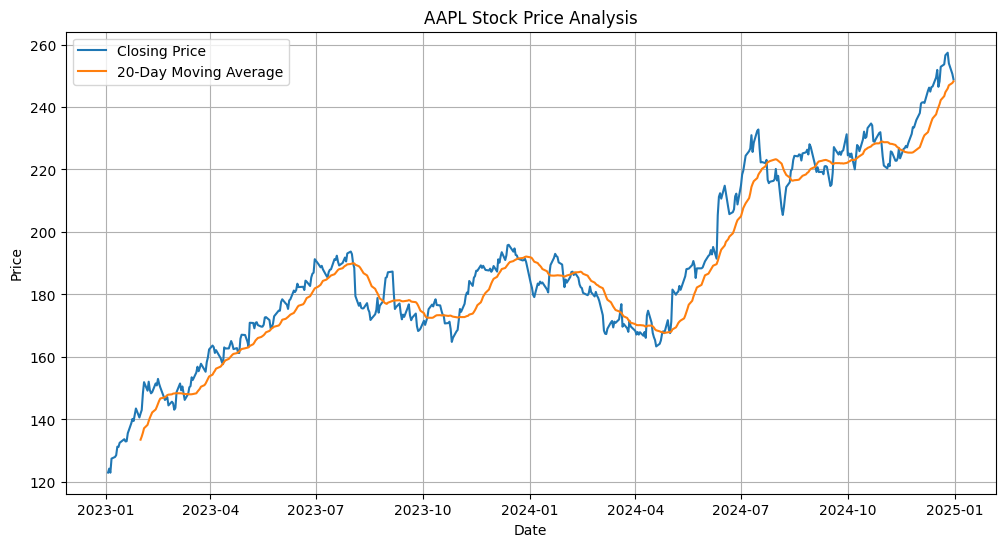

In [3]:
# Install libraries
!pip install yfinance pandas matplotlib --quiet

# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Stock ticker
ticker = "AAPL"

# Download stock data
data = yf.download(ticker, start="2023-01-01", end="2025-01-01")

print("========== STOCK PRICE ANALYSIS ==========\n")

# Display first rows
print("First 5 Records:")
print(data.head())

# Close price ko Series me convert karo
close_prices = data["Close"].squeeze()

# Basic Statistics
highest_price = float(data["High"].max().iloc[0] if hasattr(data["High"].max(), "iloc") else data["High"].max())
lowest_price = float(data["Low"].min().iloc[0] if hasattr(data["Low"].min(), "iloc") else data["Low"].min())
avg_price = float(close_prices.mean())

print("\nHighest Price:", round(highest_price, 2))
print("Lowest Price:", round(lowest_price, 2))
print("Average Closing Price:", round(avg_price, 2))

# Trend Analysis
first_price = float(close_prices.iloc[0])
last_price = float(close_prices.iloc[-1])

if last_price > first_price:
    trend = "UPWARD 📈"
else:
    trend = "DOWNWARD 📉"

print("\nOverall Trend:", trend)

# Moving Average
data["MA20"] = close_prices.rolling(window=20).mean()

# Plot Graph
plt.figure(figsize=(12,6))
plt.plot(close_prices, label="Closing Price")
plt.plot(data["MA20"], label="20-Day Moving Average")
plt.title(f"{ticker} Stock Price Analysis")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()